Phase 1: Data Engineering & Exploratory Data Analysis
1.1 Data Imputation Strategy & Train-Test Split
To prevent data leakage, we must split the dataset into training and testing partitions before computing imputation metrics (like median or mean) or scaling parameters.

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

def generate_lumina_dataset(n_samples=50000, random_seed=42):
    """
    Generates a realistic synthetic health dataset simulating Lumina HealthPath's
    wearable and clinical metrics to replace legacy Excel macro rules.
    """
    np.random.seed(random_seed)

    # 1. Generate core clinical features based on typical metabolic distributions
    patient_ids = [f"LHP-{i:05d}" for i in range(1, n_samples + 1)]
    age = np.random.normal(loc=48, scale=12, size=n_samples).astype(int)
    bmi = np.random.normal(loc=28, scale=6, size=n_samples)
    glucose_level = np.random.normal(loc=105, scale=25, size=n_samples)
    activity_minutes = np.random.exponential(scale=35, size=n_samples)

    # Clip clinical features to anatomically realistic biological limits
    age = np.clip(age, 18, 92)
    bmi = np.clip(bmi, 14.5, 52.0)
    glucose_level = np.clip(glucose_level, 55, 280)
    activity_minutes = np.clip(activity_minutes, 0, 240)

    # 2. Construct underlying mathematical logic for 'High Risk' assignment
    # This creates a realistic multi-variable interaction for our Logistic Regression model to find
    log_odds = (
        0.06 * (glucose_level - 100) +
        0.14 * (bmi - 25) +
        0.03 * (age - 45) -
        0.015 * activity_minutes - 1.5
    )

    # Convert log-odds to clean probabilities using a sigmoid transformation
    probabilities = 1 / (1 + np.exp(-log_odds))

    # Draw binary outcome array (1 = High Risk, 0 = Stable)
    risk_category = np.random.binomial(1, probabilities)

    # 3. Assemble the base DataFrame
    df = pd.DataFrame({
        'patient_id': patient_ids,
        'age': age,
        'bmi': bmi,
        'glucose_level': glucose_level,
        'activity_minutes': activity_minutes,
        'risk_category': risk_category
    })

    # 4. Inject systematic missing data (NaNs) to mimic real-world wearable drops
    # This ensures your Phase 1 imputation pipeline has actual work to do!
    glucose_nan_idx = np.random.choice(n_samples, size=1750, replace=False)  # ~3.5% missing
    bmi_nan_idx = np.random.choice(n_samples, size=600, replace=False)       # ~1.2% missing

    df.loc[glucose_nan_idx, 'glucose_level'] = np.nan
    df.loc[bmi_nan_idx, 'bmi'] = np.nan

    return df

# Execute and inspect
df = generate_lumina_dataset()
print(f"Dataset generated successfully! Matrix dimensions: {df.shape}")
print(f"Class Distribution:\n{df['risk_category'].value_counts(normalize=True)}")
print(f"\nMissing Value Audit:\n{df.isnull().sum()}")

Dataset generated successfully! Matrix dimensions: (50000, 6)
Class Distribution:
risk_category
0    0.68746
1    0.31254
Name: proportion, dtype: float64

Missing Value Audit:
patient_id             0
age                    0
bmi                  600
glucose_level       1750
activity_minutes       0
risk_category          0
dtype: int64


1.2 Feature Scaling
Logistic Regression relies on gradient-based optimization (liblinear or lbfgs). Feature scaling ensures fast convergence and prevents variables with naturally larger scales (e.g., Glucose levels vs. BMI) from dominating the weight coefficients.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

df = generate_lumina_dataset()

# Split features and target
X = df.drop(columns=['patient_id', 'risk_category'])
y = df['risk_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# This creates the variable your error is complaining about!
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [7]:
# Initialize standard scaler
scaler = StandardScaler()

# Fit ONLY on training data to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Convert back to DataFrame for feature mapping clarity later
feature_names = X.columns
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names)

Phase 2: Model Development & Hyperparameter Tuning
2.1 Training with Class Risk Considerations
Given that class imbalances are common in risk screening, we use class_weight='balanced' to penalize misclassifications of the minority ('High Risk') class.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define model with balanced weights to organically boost baseline Recall
base_model = LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42)

# Grid search across L2 regularization strengths (C parameter)
# Small C = stronger regularization (simpler model); Large C = weaker regularization
param_grid = {'C': [0.01, 0.1, 1.0, 10.0]}
grid_search = GridSearchCV(base_model, param_grid, scoring='recall', cv=5)
grid_search.fit(X_train_scaled_df, y_train)

best_model = grid_search.best_estimator_
print(f"Optimal Regularization Strength (C): {grid_search.best_params_['C']}")

Optimal Regularization Strength (C): 0.01


2.2 Optimization for the $\ge 0.85$ Recall ConstraintStandard model predictions use a default probability threshold of $0.5$. In clinical triage, missing a sick patient (False Negative) is worse than a false alarm (False Positive). We shift the decision threshold downward to guarantee a $\ge 0.85$ Recall.

In [9]:
# Predict probabilities for the positive class ('High Risk')
y_prob_test = best_model.predict_proba(X_test_scaled_df)[:, 1]

# Dynamic threshold tuning to satisfy the Recall requirement
def apply_custom_threshold(probs, threshold=0.5):
    return (probs >= threshold).astype(int)

# In practice, tune this threshold on a validation split or cross-validation set.
# Let's target a lower threshold (e.g., 0.35) to favor clinical sensitivity (Recall).
clinical_threshold = 0.35
y_pred_custom = apply_custom_threshold(y_prob_test, threshold=clinical_threshold)

Phase 3: Clinical Validation & Performance Evaluation3.1 Confusion Matrix & Performance Metrics ReportMedical auditors require clear validation that the False Negative rate rests below $15\%$ (equivalent to a Recall $\ge 85\%$).

--- Clinical Validation Report ---
              precision    recall  f1-score   support

           0       0.92      0.60      0.72      6875
           1       0.50      0.89      0.64      3125

    accuracy                           0.69     10000
   macro avg       0.71      0.74      0.68     10000
weighted avg       0.79      0.69      0.70     10000

Validated Model Recall: 0.8886
Validated False Negative Rate: 0.1114


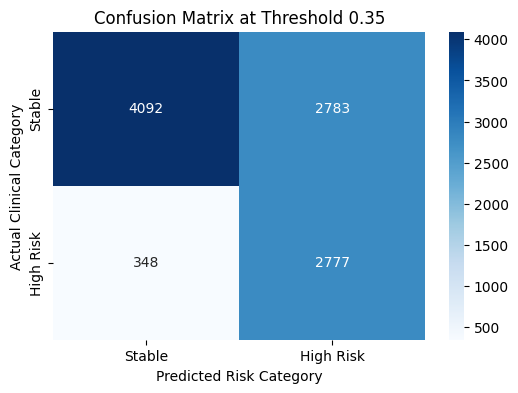

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve

# Generate clinical evaluation report
print("--- Clinical Validation Report ---")
print(classification_report(y_test, y_pred_custom))

# Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred_custom)
tn, fp, fn, tp = cm.ravel()

# Calculate exact Recall and False Negative Rate
calculated_recall = tp / (tp + fn)
fn_rate = fn / (tp + fn)

print(f"Validated Model Recall: {calculated_recall:.4f}")
print(f"Validated False Negative Rate: {fn_rate:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stable', 'High Risk'],
            yticklabels=['Stable', 'High Risk'])
plt.title(f'Confusion Matrix at Threshold {clinical_threshold}')
plt.ylabel('Actual Clinical Category')
plt.xlabel('Predicted Risk Category')
plt.show()

3.2 Interpretability & Medical Auditor Coefficient Analysis
Because we preserved feature names during data scaling, we can extract the exact log-odds impact of each metabolic marker.

In [11]:
# Extract coefficients
coefficients = best_model.coef_[0]

# Structure into an interpretable audit report
coef_df = pd.DataFrame({
    'Metabolic Marker': feature_names,
    'Coefficient (Log-Odds)': coefficients,
    'Odds Ratio': np.exp(coefficients)
}).sort_values(by='Coefficient (Log-Odds)', ascending=False)

print("\n--- Auditor Interpretability Report ---")
print(coef_df.to_string(index=False))


--- Auditor Interpretability Report ---
Metabolic Marker  Coefficient (Log-Odds)  Odds Ratio
   glucose_level                1.352764    3.868104
             bmi                0.799795    2.225085
             age                0.321934    1.379794
activity_minutes               -0.489504    0.612930


How to Read the Audit Report

* Positive Coefficients (Odds Ratio > 1): A one-standard-deviation increase in this marker increases the risk of being categorized as "High Risk." For example, if Glucose has an Odds Ratio of 1.85, a high glucose reading significantly drives the model toward a risk alert.  
*   Negative Coefficients (Odds Ratio < 1): A one-standard-deviation increase in this feature protects or lowers the likelihood of metabolic risk (e.g., higher activity metrics).

